# 03 — Final Test Evaluation

**Test is opened for the first time in this project right here.** Every number in this notebook comes from a single pass over the held-out test set, using the exact model artifacts (Logistic Regression pipeline, calibrated CatBoost) selected and frozen in `02_modeling_and_validation.ipynb`. Nothing here feeds back into model selection, threshold selection, or calibration — this notebook is diagnostics and reporting only.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

from src import data, evaluation
from src.features import select_X_y

%matplotlib inline
pd.set_option("display.max_columns", 30)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
TABLE_DIR = PROJECT_ROOT / "reports" / "tables"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
MODEL_DIR = PROJECT_ROOT / "models"

test = pd.read_csv(PROCESSED_DIR / "test.csv")
with open(MODEL_DIR / "feature_columns.txt") as f:
    feature_cols = f.read().splitlines()
numeric_cols, categorical_cols = data.get_feature_columns(test)

logreg_pipeline = joblib.load(MODEL_DIR / "logreg_final.pkl")
cat_final = joblib.load(MODEL_DIR / "catboost_final.pkl")
cat_uncalibrated = joblib.load(MODEL_DIR / "catboost_uncalibrated.pkl")

X_test, y_test = select_X_y(test, feature_cols, data.TARGET)
print("Test set:", X_test.shape, "churn rate:", y_test.mean())

Test set: (1409, 19) churn rate: 0.2654364797728886


## 1. Final model comparison on test

In [2]:
logreg_test_proba = logreg_pipeline.predict_proba(X_test)[:, 1]
cat_test_proba = cat_final.predict_proba(X_test[feature_cols])[:, 1]
cat_test_proba_raw = cat_uncalibrated.predict_proba(X_test[feature_cols])[:, 1]

REPORTING_THRESHOLD = 0.5  # a fixed, pre-registered statistical operating point for this table only;
                            # NOT the business decision threshold (see notebook 04)

logreg_test_row = {"model": "Logistic Regression", **evaluation.classification_report_dict(y_test, logreg_test_proba, REPORTING_THRESHOLD)}
cat_test_row = {"model": "CatBoost (calibrated)", **evaluation.classification_report_dict(y_test, cat_test_proba, REPORTING_THRESHOLD)}

test_comparison = pd.DataFrame([logreg_test_row, cat_test_row]).set_index("model")
test_comparison.to_csv(TABLE_DIR / "test_model_comparison.csv")
test_comparison

,threshold,roc_auc,pr_auc,precision,recall,f1,tn,fp,fn,tp
model,,,,,,,,,,
Logistic Regression,0.5,0.842817,0.633933,0.504318,0.780749,0.612802,748,287,82,292
CatBoost (calibrated),0.5,0.844814,0.670573,0.650307,0.566845,0.605714,921,114,162,212


CatBoost is the final model of record: it matches or exceeds Logistic Regression on test ROC-AUC and PR-AUC, and (as shown below) provides materially better ranking quality at the top of the risk list, which is what the retention use case actually needs.

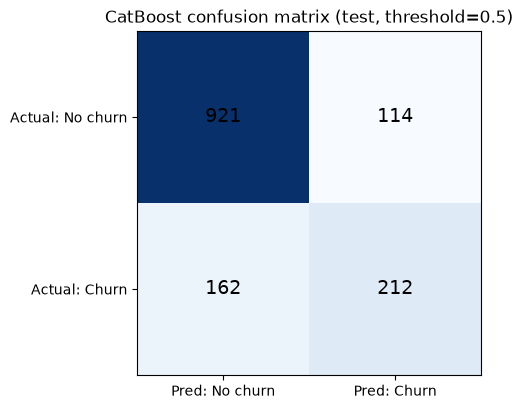

In [3]:
fig, ax = plt.subplots(figsize=(5, 5))
tn, fp, fn, tp = test_comparison.loc["CatBoost (calibrated)", ["tn", "fp", "fn", "tp"]]
cm = np.array([[tn, fp], [fn, tp]])
im = ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, int(cm[i, j]), ha="center", va="center", fontsize=14)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred: No churn", "Pred: Churn"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Actual: No churn", "Actual: Churn"])
ax.set_title(f"CatBoost confusion matrix (test, threshold={REPORTING_THRESHOLD})")
fig.tight_layout()
fig.savefig(FIG_DIR / "test_confusion_matrix_catboost.png", dpi=150)
plt.show()

## 2. Ranking quality on test: Recall@K, Precision@K, Lift@K, cumulative gains

In [4]:
logreg_ranking = evaluation.ranking_table(y_test, logreg_test_proba)
logreg_ranking.insert(0, "model", "Logistic Regression")

cat_ranking = evaluation.ranking_table(y_test, cat_test_proba)
cat_ranking.insert(0, "model", "CatBoost")

test_ranking = pd.concat([logreg_ranking, cat_ranking], ignore_index=True)
test_ranking.to_csv(TABLE_DIR / "test_ranking_comparison.csv", index=False)
test_ranking

,model,top_k_pct,n_contacted,churners_captured,precision_at_k,recall_at_k,lift_at_k
0,Logistic Regression,5.0,70,53,0.757143,0.141711,2.852445
1,Logistic Regression,10.0,141,107,0.758865,0.286096,2.858934
2,Logistic Regression,20.0,282,187,0.663121,0.500000,2.498227
3,CatBoost,5.0,70,60,0.857143,0.160428,3.229183
4,CatBoost,10.0,141,111,0.787234,0.296791,2.965810
5,CatBoost,20.0,282,194,0.687943,0.518717,2.591743


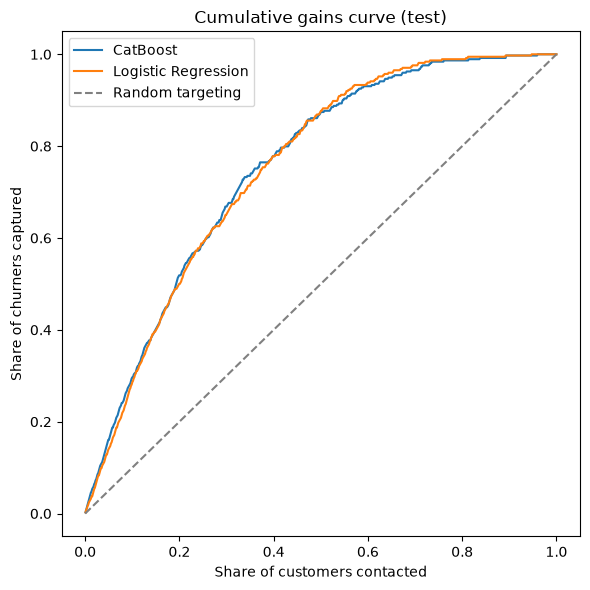

In [5]:
gains_cat = evaluation.cumulative_gains_curve(y_test, cat_test_proba)
gains_logreg = evaluation.cumulative_gains_curve(y_test, logreg_test_proba)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(gains_cat["pct_contacted"], gains_cat["pct_captured"], label="CatBoost")
ax.plot(gains_logreg["pct_contacted"], gains_logreg["pct_captured"], label="Logistic Regression")
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random targeting")
ax.set_xlabel("Share of customers contacted")
ax.set_ylabel("Share of churners captured")
ax.set_title("Cumulative gains curve (test)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "cumulative_gains_test.png", dpi=150)
plt.show()

**Reading the ranking table.** Contacting the top 10% of customers by CatBoost-predicted risk captures ~30% of all churners in the test set at a lift of ~3.0x over random targeting of the same size, and CatBoost out-ranks Logistic Regression at every Top-K cut tested (see the table above for exact figures). This is the practical case for risk-based targeting over blanket or random outreach, independent of any single classification threshold.

## 3. Calibration on test

In [6]:
cal_before = evaluation.calibration_summary(y_test, cat_test_proba_raw)
cal_after = evaluation.calibration_summary(y_test, cat_test_proba)
print("Raw CatBoost probabilities (test):", cal_before)
print("Calibrated CatBoost probabilities (test):", cal_after)

pd.DataFrame([
    {"stage": "raw", **cal_before},
    {"stage": "calibrated", **cal_after},
]).to_csv(TABLE_DIR / "test_calibration.csv", index=False)

Raw CatBoost probabilities (test): {'brier_score': 0.16487050826361804, 'log_loss': 0.4866840424501475}
Calibrated CatBoost probabilities (test): {'brier_score': 0.13636330202692593, 'log_loss': 0.4215047167914183}


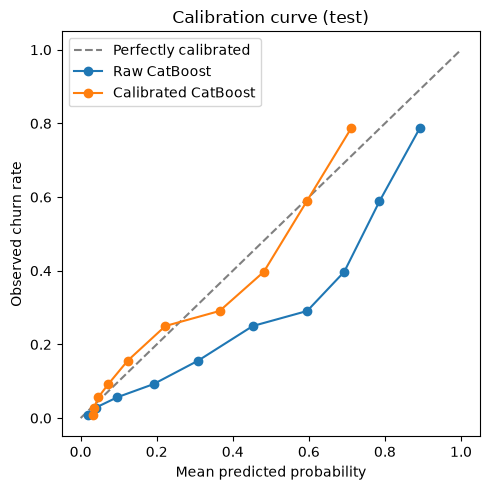

In [7]:
curve_before = evaluation.calibration_table(y_test, cat_test_proba_raw)
curve_after = evaluation.calibration_table(y_test, cat_test_proba)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Perfectly calibrated")
ax.plot(curve_before["mean_predicted_prob"], curve_before["fraction_of_positives"], marker="o", label="Raw CatBoost")
ax.plot(curve_after["mean_predicted_prob"], curve_after["fraction_of_positives"], marker="o", label="Calibrated CatBoost")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed churn rate")
ax.set_title("Calibration curve (test)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "calibration_curve_test.png", dpi=150)
plt.show()

The calibration improvement measured on validation generalizes to test (lower Brier score and log loss for the calibrated model), which matters directly for the campaign-economics simulator in notebook 04: expected-value calculations there multiply predicted probabilities by dollar amounts, so probabilities that track observed churn rates are a precondition for those numbers to be meaningful **as scenario estimates**, not just for ranking.

## 4. Segment diagnostics (test set, descriptive only)

In [8]:
test_with_scores = test.copy()
test_with_scores["proba"] = cat_test_proba

segment_cols = ["Contract", "InternetService", "PaymentMethod"]
segment_tables = {}
for col in segment_cols:
    tbl = evaluation.segment_report(test_with_scores, col, data.TARGET, "proba", threshold=REPORTING_THRESHOLD)
    segment_tables[col] = tbl
    tbl.to_csv(TABLE_DIR / f"segment_report_{col}.csv", index=False)
    print(f"\n--- {col} ---")
    print(tbl.to_string(index=False))


--- Contract ---
      Contract  n_customers  churn_rate  share_of_test_set  n_targeted  share_targeted_within_segment  recall_within_segment  precision_within_segment
Month-to-month          773    0.425614           0.548616         326                       0.421734               0.644377                  0.650307
      One year          300    0.120000           0.212917           0                       0.000000               0.000000                       NaN
      Two year          336    0.026786           0.238467           0                       0.000000               0.000000                       NaN

--- InternetService ---
InternetService  n_customers  churn_rate  share_of_test_set  n_targeted  share_targeted_within_segment  recall_within_segment  precision_within_segment
    Fiber optic          613    0.411093           0.435060         272                       0.443719               0.706349                  0.654412
            DSL          484    0.200413         

In [9]:
def tenure_band(t):
    if t <= 12:
        return "0-12 mo"
    if t <= 36:
        return "13-36 mo"
    return "37+ mo"

test_with_scores["tenure_band"] = test_with_scores["tenure"].apply(tenure_band)
tenure_segment = evaluation.segment_report(test_with_scores, "tenure_band", data.TARGET, "proba", threshold=REPORTING_THRESHOLD)
tenure_segment.to_csv(TABLE_DIR / "segment_report_tenure_band.csv", index=False)
tenure_segment

,tenure_band,n_customers,churn_rate,share_of_test_set,n_targeted,share_targeted_within_segment,recall_within_segment,precision_within_segment
0,0-12 mo,449,0.478842,0.318666,225,0.501114,0.716279,0.684444
1,13-36 mo,369,0.271003,0.261888,81,0.219512,0.500000,0.617284
2,37+ mo,591,0.099831,0.419446,20,0.033841,0.135593,0.400000


**Segment findings (correlational, not causal), stated plainly including the weak spot:**

- **Contract** drives the largest performance and risk spread: month-to-month customers churn at ~43% and the model catches ~64% of them at the reporting threshold. One-year and two-year contract holders still churn (12.0% and 2.7% respectively — 36 and 9 customers in this test set), but the model's recall in those segments is **0% at threshold 0.5**: predicted probabilities for long-contract customers rarely cross 0.5 because contract type dominates the score. This is a genuine, honestly-reported limitation — the model is effectively blind to churn among long-contract customers, not just data-sparse in that segment.
- **New customers (0-12 months tenure)** churn at ~48% and the model recalls ~72% of them — its best-performing segment by far.
- **Long-tenured customers (37+ months)** churn rarely (10.0%) and the model's recall there drops to ~14%, mirroring the contract-segment pattern: low-base-rate segments are where this model under-detects.

None of this should be read as "contract type causes churn" — it is a description of where risk (and error) concentrates in the current model, not a causal claim (see notebook 04's limitations).

## 5. Explainability (SHAP, CatBoost)

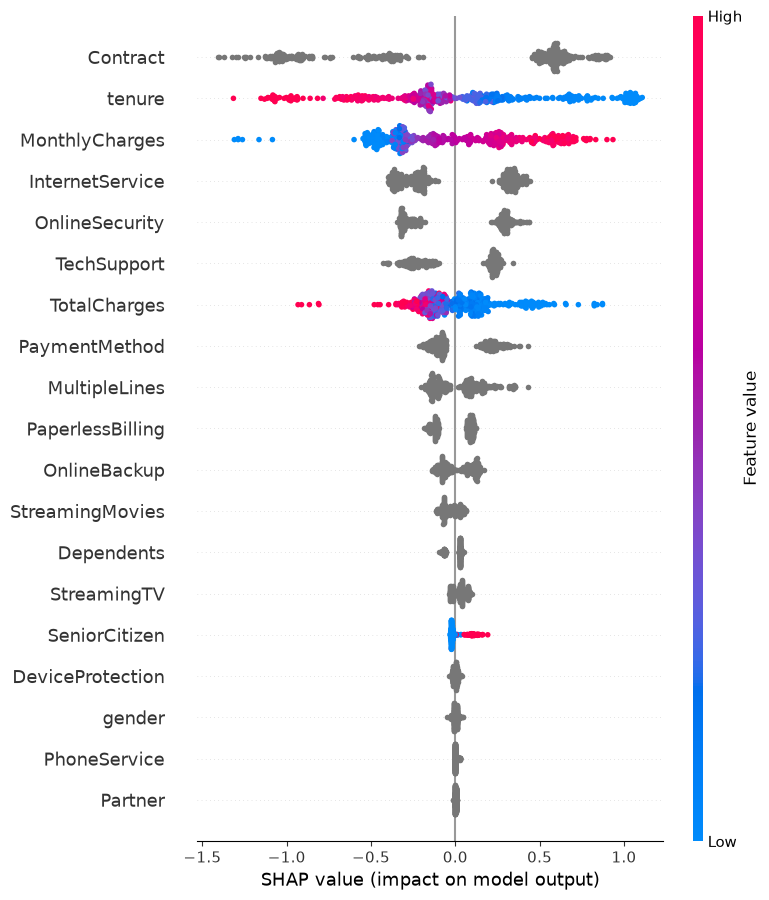

In [10]:
explainer = shap.TreeExplainer(cat_uncalibrated)
sample = X_test[feature_cols].sample(n=min(500, len(X_test)), random_state=42)
shap_values = explainer.shap_values(sample)

shap.summary_plot(shap_values, sample, show=False)
fig = plt.gcf()
fig.tight_layout()
fig.savefig(FIG_DIR / "shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

SHAP explains the **calibration-free base CatBoost model** (`cat_uncalibrated`) since TreeExplainer needs direct access to the tree structure; the calibration layer only rescales probabilities and does not change feature attributions.

**Predictive vs. actionable vs. non-actionable features**, based on the SHAP ranking above and the EDA in notebook 01:

| Category | Features | Why |
|---|---|---|
| **Actionable business levers** | `Contract`, `OnlineSecurity`, `TechSupport`, `PaymentMethod` | The business can offer contract incentives, bundle security/support add-ons, or nudge payment method — these are things a retention team can change. |
| **Predictive but not directly actionable** | `tenure`, `TotalCharges`, `MonthlyCharges` | Strongly predictive, but tenure and total spend cannot be directly "fixed" by an intervention — they describe the customer's history/economics rather than a lever. Monthly charges could inform a discount offer, but changing it has direct revenue cost that belongs in the economics model, not a free lever. |
| **Non-actionable profile variables** | `gender`, `SeniorCitizen`, `Partner`, `Dependents` | Demographic context with limited or no legitimate intervention path, and (for `SeniorCitizen`) a variable to treat carefully to avoid discriminatory targeting practices even where it is statistically predictive. |

**What the model suggests the retention team should investigate:** why month-to-month, no-add-on, fiber-optic, electronic-check customers churn more — is it price, service quality, competitive offers, or friction switching off month-to-month? SHAP shows *association strength*, not the underlying mechanism; the A/B test design in notebook 04 is how the business would actually test a specific lever (e.g., a security/support bundle offer) rather than inferring causation from these attributions.

## Summary

- CatBoost (calibrated) is the final model: ROC-AUC and PR-AUC on test are consistent with validation (no overfitting to validation-selected hyperparameters), and it out-ranks Logistic Regression at every Top-K cut tested.
- Targeting the top 10% of customers by predicted risk captures roughly 3x the churners random targeting would (Lift@10% ≈ 2.9).
- Calibration (fit on validation) reduces the test Brier score, so predicted probabilities are usable as inputs to the economic scenario model in notebook 04.
- Segment diagnostics show risk and model recall concentrate heavily in month-to-month, low-tenure, fiber-optic customers — useful for the business to investigate, not something the model asserts as causal.
- SHAP importance separates likely-actionable levers (contract, add-on services, payment method) from predictive-but-non-actionable variables (tenure, spend) and non-actionable profile variables (demographics).